# AMC a bajo SNR — Opción 6: Fusión de representaciones (I/Q + HOS + STFT)

Entrena `FusionClassifier` (`../common_snr/models.py`): combina I/Q crudo, momentos/cumulantes
de orden superior (HOS) y espectrograma STFT de la misma señal en un solo modelo — cada
representación pasa por su propia rama liviana hasta un embedding chico, y los 3 embeddings se
concatenan antes de clasificar.

**Hipótesis**: cada representación es robusta a bajo SNR por una razón distinta (HOS ante
ruido gaussiano, STFT ante estructura dispersa en tiempo/frecuencia, I/Q retiene toda la
información sin pérdida de por medio) — combinarlas podría compensar los puntos débiles de
cada una por separado, en vez de competir entre sí como en `../comparacion/comparacion.ipynb`.

**Detalle de implementación**: para poder seguir usando `common/train_model`,
`common/evaluate_by_snr`, etc. **sin modificarlos** (esperan un solo tensor `X`, no 3), las 3
representaciones se empaquetan en un único vector plano por muestra
(`features.pack_fusion_features`) y `FusionClassifier.forward` las desempaqueta internamente.

Ver `../README.md` para el resto de las estrategias evaluadas y por qué.


## 1. Imports y configuración

In [1]:
import sys
sys.path.insert(0, "../../Modelos iniciales")  # common/: data.py, train.py (no se duplican acá)
sys.path.insert(0, "..")                       # common_snr/: features.py, models.py de esta carpeta

import pickle

import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from common_snr.models import FusionClassifier
from common_snr.features import compute_hos_features, compute_stft, pack_fusion_features
from common.data import load_radioml_digital, split_dataset, make_loader
from common.train import train_model, evaluate_by_snr, overall_accuracy, compute_cm

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 256
EPOCHS = 50
PATIENCE = 10
SEED = 42

# Hiperparámetros de arquitectura — modificar acá para probar otra profundidad/ancho.
# iq_shape/hos_dim/stft_shape se completan en la próxima celda a partir de los datos reales
# (dependen de nperseg/noverlap de compute_stft) — acá solo van embed_dim/conv_channels/dropout.
MODEL_KWARGS = dict(embed_dim=16, conv_channels=16, kernel_size=3, dropout=0.3)

print(f"Usando dispositivo: {DEVICE}")

Usando dispositivo: cpu


## 2. Carga, split y fusión de representaciones

In [2]:
X, y, snrs, le = load_radioml_digital(dataset_folder="../../Modelos iniciales/rfml", seed=SEED)
N_CLASSES = len(le.classes_)
print(f"Clases ({N_CLASSES}): {list(le.classes_)}")

(X_train, y_train, snr_train), (X_val, y_val, snr_val), (X_test, y_test, snr_test) = split_dataset(
    X, y, snrs, seed=SEED
)

# Cada split se transforma a las 3 representaciones y se empaquetan en un solo vector por
# muestra — ver pack_fusion_features. Guardamos las shapes reales (IQ_SHAPE, HOS_DIM,
# STFT_SHAPE) para poder reconstruir el modelo después con el mismo desempaquetado exacto.
IQ_SHAPE = X_train.shape[1:]
X_train_hos, X_val_hos, X_test_hos = compute_hos_features(X_train), compute_hos_features(X_val), compute_hos_features(X_test)
HOS_DIM = X_train_hos.shape[1]
X_train_stft, X_val_stft, X_test_stft = compute_stft(X_train), compute_stft(X_val), compute_stft(X_test)
STFT_SHAPE = X_train_stft.shape[1:]

X_train_iq, X_val_iq, X_test_iq = X_train, X_val, X_test  # nombres explícitos antes de sobreescribir X_train/etc.
X_train = pack_fusion_features(X_train_iq, X_train_hos, X_train_stft)
X_val = pack_fusion_features(X_val_iq, X_val_hos, X_val_stft)
X_test = pack_fusion_features(X_test_iq, X_test_hos, X_test_stft)

MODEL_KWARGS = dict(**MODEL_KWARGS, iq_shape=IQ_SHAPE, hos_dim=HOS_DIM, stft_shape=STFT_SHAPE)
print(f"IQ_SHAPE={IQ_SHAPE}, HOS_DIM={HOS_DIM}, STFT_SHAPE={STFT_SHAPE}")
print(f"Train empaquetado: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

train_loader = make_loader(X_train, y_train, batch_size=BATCH_SIZE, shuffle=True)
val_loader = make_loader(X_val, y_val, batch_size=BATCH_SIZE, shuffle=False)

Clases (8): ['8PSK', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK']
IQ_SHAPE=(2, 128), HOS_DIM=16, STFT_SHAPE=(2, 32, 9)
Train empaquetado: (96000, 848) | Val: (32000, 848) | Test: (32000, 848)


## 3. Entrenamiento — Fusión (I/Q + HOS + STFT)

In [3]:
print("=== Fusión (I/Q + HOS + STFT) ===")
print(f"Configuración: {MODEL_KWARGS}")
model = FusionClassifier(n_classes=N_CLASSES, **MODEL_KWARGS)
print(f"Parámetros: {model.count_parameters():,}")

model, history = train_model(
    model, train_loader, val_loader,
    epochs=EPOCHS, patience=PATIENCE, device=DEVICE
)
history["model_kwargs"] = MODEL_KWARGS

torch.save(model.state_dict(), "fusion.pt")
with open("history.pkl", "wb") as f:
    pickle.dump(history, f)

=== Fusión (I/Q + HOS + STFT) ===
Configuración: {'embed_dim': 16, 'conv_channels': 16, 'kernel_size': 3, 'dropout': 0.3, 'iq_shape': (2, 128), 'hos_dim': 16, 'stft_shape': (2, 32, 9)}
Parámetros: 2,552
Época  10/50 | Train Loss: 1.1380 | Val Loss: 6.1975 | Val Acc: 0.2051 | Patience: 4/10
Época  16/50 | Train Loss: 1.1139 | Val Loss: 94.2320 | Val Acc: 0.1250 | Patience: 10/10
Early stopping en época 16. Mejor val_loss: 4.8887


## 4. Evaluación (foco en bajo SNR)

In [4]:
acc = overall_accuracy(model, X_test, y_test, device=DEVICE)
snr_acc = evaluate_by_snr(model, X_test, y_test, snr_test, device=DEVICE)

print(f"Accuracy global — Fusión: {acc:.4f}")
print(f"Parámetros: {model.count_parameters():,}")

# El límite físico de información de Fisher para AMC está, en la práctica, entre -10 y -14 dB
# (ver ../README.md) — reportamos aparte la accuracy por debajo y por encima de ese umbral.
mask_muy_bajo = snr_test <= -10
mask_resto = snr_test > -10
acc_muy_bajo = overall_accuracy(model, X_test[mask_muy_bajo], y_test[mask_muy_bajo], device=DEVICE)
acc_resto = overall_accuracy(model, X_test[mask_resto], y_test[mask_resto], device=DEVICE)
print(f"Accuracy SNR <= -10 dB: {acc_muy_bajo:.4f} (n={mask_muy_bajo.sum()})")
print(f"Accuracy SNR >  -10 dB: {acc_resto:.4f} (n={mask_resto.sum()})")

Accuracy global — Fusión: 0.1961
Parámetros: 2,552
Accuracy SNR <= -10 dB: 0.1294 (n=9641)
Accuracy SNR >  -10 dB: 0.2249 (n=22359)


## 5. Gráficos

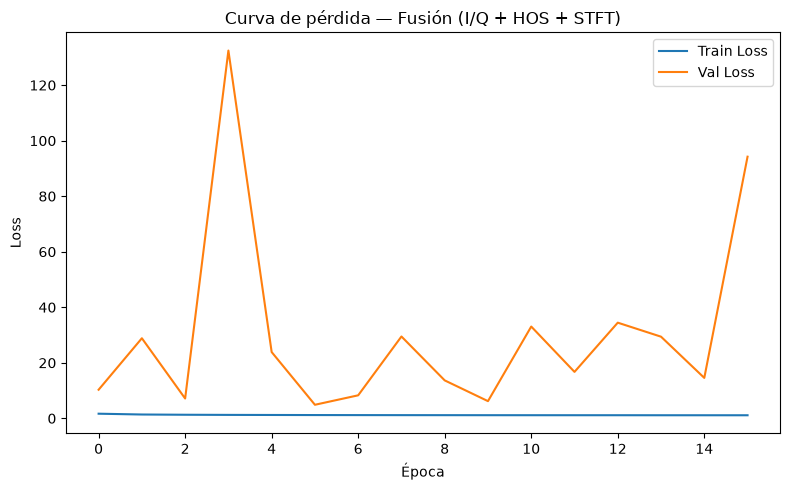

In [5]:
# Curva de pérdida
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Curva de pérdida — Fusión (I/Q + HOS + STFT)")
plt.legend()
plt.tight_layout()
plt.savefig("curva_perdida.png", dpi=150)
plt.show()

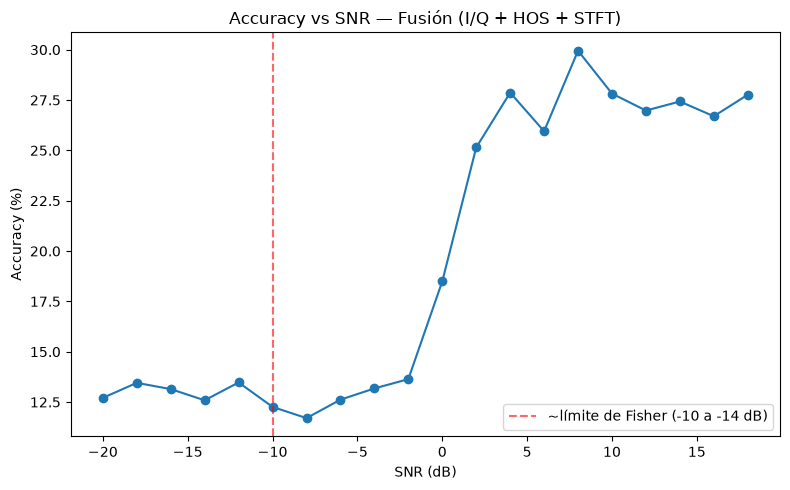

In [6]:
# Accuracy vs SNR — con línea de referencia en -10 dB (límite físico aproximado, ver README)
snr_levels = sorted(snr_acc.keys())
plt.figure(figsize=(8, 5))
plt.plot(snr_levels, [snr_acc[s] * 100 for s in snr_levels], marker="o")
plt.axvline(-10, color="red", linestyle="--", alpha=0.6, label="~límite de Fisher (-10 a -14 dB)")
plt.xlabel("SNR (dB)")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs SNR — Fusión (I/Q + HOS + STFT)")
plt.legend()
plt.tight_layout()
plt.savefig("accuracy_vs_snr.png", dpi=150)
plt.show()

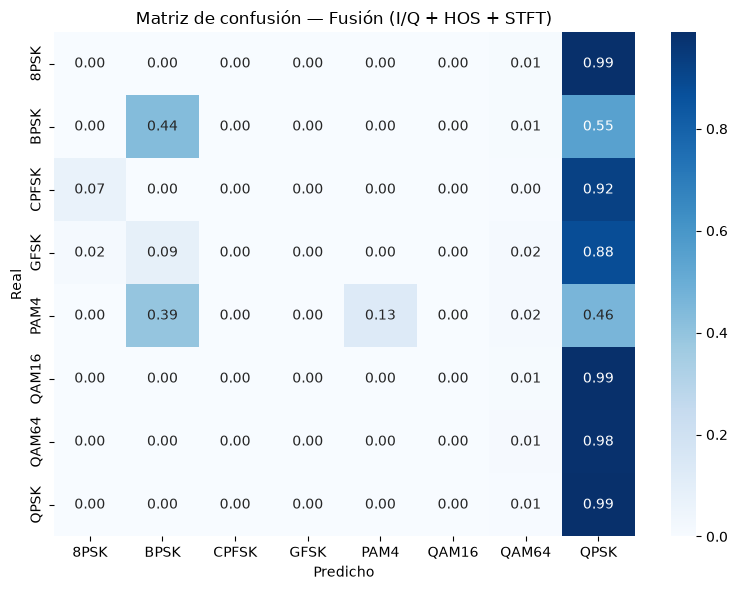

In [7]:
# Matriz de confusión (todos los SNR)
cm = compute_cm(model, X_test, y_test, device=DEVICE)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=".2f", xticklabels=le.classes_, yticklabels=le.classes_,
            cmap="Blues", ax=ax)
ax.set_xlabel("Predicho")
ax.set_ylabel("Real")
ax.set_title("Matriz de confusión — Fusión (I/Q + HOS + STFT)")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

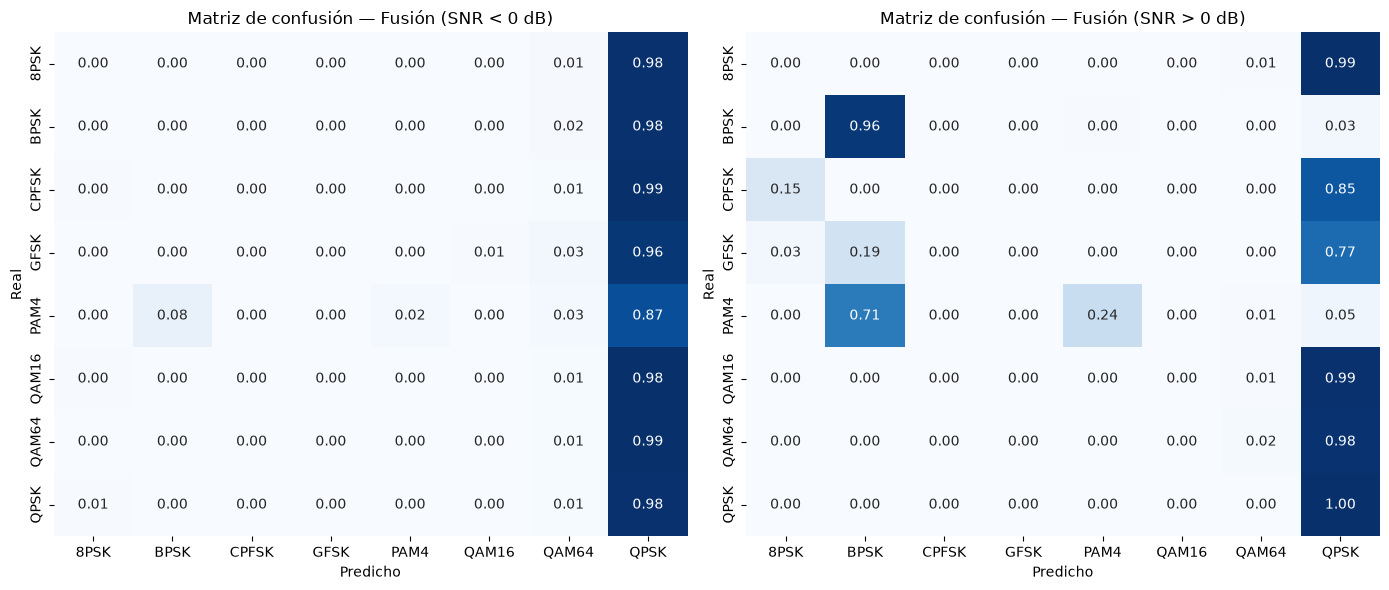

In [8]:
# Matrices de confusión por rango de SNR (bajo: <0 dB, alto: >0 dB)
mask_low = snr_test < 0
mask_high = snr_test > 0

cm_low = compute_cm(model, X_test[mask_low], y_test[mask_low], device=DEVICE)
cm_high = compute_cm(model, X_test[mask_high], y_test[mask_high], device=DEVICE)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, cm_snr, titulo_snr in zip(axes, [cm_low, cm_high], ["SNR < 0 dB", "SNR > 0 dB"]):
    sns.heatmap(cm_snr, annot=True, fmt=".2f", xticklabels=le.classes_, yticklabels=le.classes_,
                cmap="Blues", ax=ax, cbar=False)
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")
    ax.set_title(f"Matriz de confusión — Fusión ({titulo_snr})")
plt.tight_layout()
plt.savefig("confusion_matrix_por_snr.png", dpi=150)
plt.show()